# Task 2-3: Fashion-MNIST + TensorBoard

Training 3 models, logging to TensorBoard, showing predictions on 5 test samples.

In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torch.utils.tensorboard import SummaryWriter
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime
import os

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Device: {device}')
os.makedirs('runs', exist_ok=True)

Device: mps


In [19]:
CLASS_NAMES = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

image_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

fashion_mnist_train_dataset = datasets.FashionMNIST(
    './data',
    train=True,
    download=True,
    transform=image_transform,
)

fashion_mnist_test_dataset = datasets.FashionMNIST(
    './data',
    train=False,
    download=True,
    transform=image_transform,
)

train_data_loader = DataLoader(
    fashion_mnist_train_dataset,
    batch_size=64,
    shuffle=True,
)

test_data_loader = DataLoader(
    fashion_mnist_test_dataset,
    batch_size=64,
)

print(f'Train: {len(fashion_mnist_train_dataset)}, Test: {len(fashion_mnist_test_dataset)}')

Train: 60000, Test: 10000


In [20]:
class SingleLayer(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(784, 10)
    def forward(self, x): return self.fc(x.view(x.size(0), -1))

class MLPNoDrop(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(784, 512), nn.ReLU(), nn.Linear(512, 256), nn.ReLU(), nn.Linear(256, 128), nn.ReLU(), nn.Linear(128, 10))
    def forward(self, x): return self.net(x.view(x.size(0), -1))

class MLPDrop(nn.Module):
    def __init__(self, p=0.5):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(784, 512), nn.ReLU(), nn.Dropout(p), nn.Linear(512, 256), nn.ReLU(), nn.Dropout(p), nn.Linear(256, 128), nn.ReLU(), nn.Dropout(p), nn.Linear(128, 10))
    def forward(self, x): return self.net(x.view(x.size(0), -1))

In [21]:
def train_and_log_to_tensorboard(model, experiment_name, num_epochs=30):
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    tb_writer = SummaryWriter(f'runs/{experiment_name}_{timestamp}')
    tb_writer.add_graph(model, torch.zeros(1, 1, 28, 28).to(device))

    loss_fn = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    history = {
        'train_loss': [],
        'train_acc': [],
        'test_loss': [],
        'test_acc': [],
    }

    for epoch_idx in range(num_epochs):
        # ---- Training ----
        model.train()
        train_loss_sum = 0.0
        train_correct = 0
        train_num_samples = 0

        for images, labels in train_data_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            logits = model(images)
            loss = loss_fn(logits, labels)
            loss.backward()
            optimizer.step()

            train_loss_sum += loss.item() * images.size(0)
            train_correct += (logits.argmax(dim=1) == labels).sum().item()
            train_num_samples += labels.size(0)

        # ---- Evaluation ----
        model.eval()
        test_loss_sum = 0.0
        test_correct = 0
        test_num_samples = 0

        with torch.no_grad():
            for images, labels in test_data_loader:
                images = images.to(device)
                labels = labels.to(device)

                logits = model(images)
                batch_loss = loss_fn(logits, labels).item()
                test_loss_sum += batch_loss * images.size(0)
                test_correct += (logits.argmax(dim=1) == labels).sum().item()
                test_num_samples += labels.size(0)

        train_loss_mean = train_loss_sum / train_num_samples
        train_acc_pct = 100.0 * train_correct / train_num_samples
        test_loss_mean = test_loss_sum / test_num_samples
        test_acc_pct = 100.0 * test_correct / test_num_samples

        history['train_loss'].append(train_loss_mean)
        history['train_acc'].append(train_acc_pct)
        history['test_loss'].append(test_loss_mean)
        history['test_acc'].append(test_acc_pct)

        tb_writer.add_scalar('Loss/train', train_loss_mean, epoch_idx)
        tb_writer.add_scalar('Loss/test', test_loss_mean, epoch_idx)
        tb_writer.add_scalar('Acc/train', train_acc_pct, epoch_idx)
        tb_writer.add_scalar('Acc/test', test_acc_pct, epoch_idx)
        tb_writer.add_scalar('Gap', train_acc_pct - test_acc_pct, epoch_idx)

        if (epoch_idx + 1) % 5 == 0:
            print(
                f'Epoch {epoch_idx + 1:2d} | '
                f'Train: {train_loss_mean:.4f}, {train_acc_pct:.1f}% | '
                f'Test: {test_loss_mean:.4f}, {test_acc_pct:.1f}%'
            )

    tb_writer.close()
    return history

In [22]:
model_by_key = {}
history_by_model_key = {}

In [23]:
print('--- Single Layer ---')
model_by_key['single_layer'] = SingleLayer().to(device)
history_by_model_key['single_layer'] = train_and_log_to_tensorboard(
    model_by_key['single_layer'],
    experiment_name='SingleLayer',
)

--- Single Layer ---
Epoch  5 | Train: 0.4163, 85.5% | Test: 0.4552, 83.9%
Epoch 10 | Train: 0.4002, 86.0% | Test: 0.4564, 83.8%
Epoch 15 | Train: 0.3904, 86.3% | Test: 0.4524, 83.9%
Epoch 20 | Train: 0.3864, 86.4% | Test: 0.4638, 83.5%
Epoch 25 | Train: 0.3829, 86.5% | Test: 0.4677, 83.7%
Epoch 30 | Train: 0.3792, 86.5% | Test: 0.4531, 83.6%


In [24]:
print('--- MLP No Dropout ---')
model_by_key['mlp_no_dropout'] = MLPNoDrop().to(device)
history_by_model_key['mlp_no_dropout'] = train_and_log_to_tensorboard(
    model_by_key['mlp_no_dropout'],
    experiment_name='MLP_NoDrop',
)

--- MLP No Dropout ---
Epoch  5 | Train: 0.2869, 89.4% | Test: 0.3460, 87.4%
Epoch 10 | Train: 0.2211, 91.6% | Test: 0.3352, 88.8%
Epoch 15 | Train: 0.1689, 93.6% | Test: 0.3852, 88.5%
Epoch 20 | Train: 0.1392, 94.6% | Test: 0.3973, 88.9%
Epoch 25 | Train: 0.1143, 95.6% | Test: 0.4738, 89.2%
Epoch 30 | Train: 0.0941, 96.4% | Test: 0.5100, 89.3%


In [25]:
print('--- MLP + Dropout ---')
model_by_key['mlp_with_dropout'] = MLPDrop(p=0.5).to(device)
history_by_model_key['mlp_with_dropout'] = train_and_log_to_tensorboard(
    model_by_key['mlp_with_dropout'],
    experiment_name='MLP_Drop',
)

--- MLP + Dropout ---
Epoch  5 | Train: 0.4536, 84.2% | Test: 0.3890, 85.8%
Epoch 10 | Train: 0.4099, 85.8% | Test: 0.3713, 86.9%
Epoch 15 | Train: 0.3859, 86.5% | Test: 0.3647, 87.1%
Epoch 20 | Train: 0.3765, 86.9% | Test: 0.3505, 87.8%
Epoch 25 | Train: 0.3589, 87.3% | Test: 0.3570, 87.8%
Epoch 30 | Train: 0.3517, 87.6% | Test: 0.3443, 87.7%


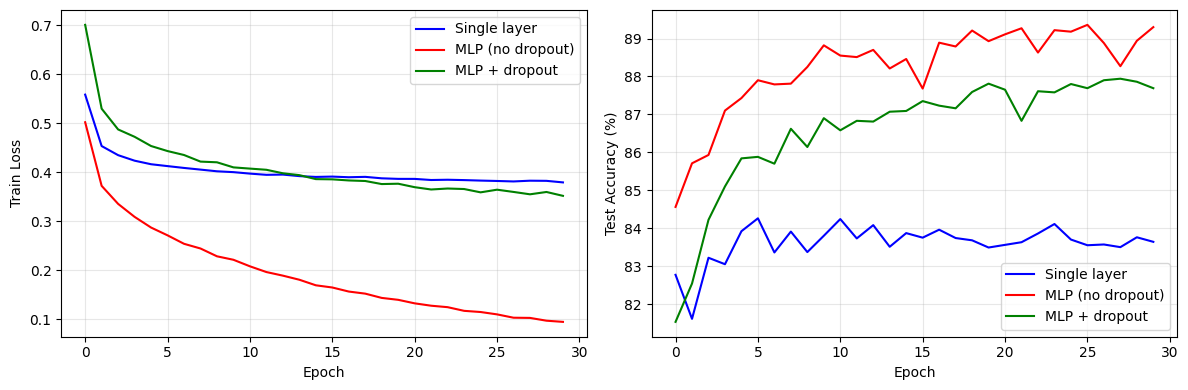

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_color_by_model_key = {
    'single_layer': 'blue',
    'mlp_no_dropout': 'red',
    'mlp_with_dropout': 'green',
}

plot_label_by_model_key = {
    'single_layer': 'Single layer',
    'mlp_no_dropout': 'MLP (no dropout)',
    'mlp_with_dropout': 'MLP + dropout',
}

for model_key in history_by_model_key:
    history = history_by_model_key[model_key]
    axes[0].plot(
        history['train_loss'],
        label=plot_label_by_model_key[model_key],
        color=plot_color_by_model_key[model_key],
    )
    axes[1].plot(
        history['test_acc'],
        label=plot_label_by_model_key[model_key],
        color=plot_color_by_model_key[model_key],
    )

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Train Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Test Accuracy (%)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

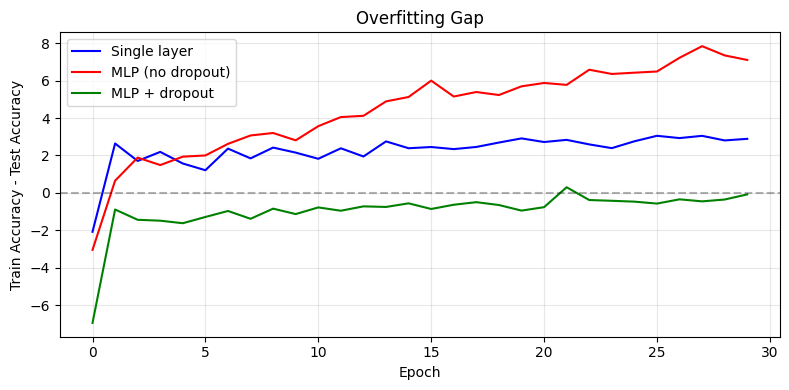

In [27]:
plt.figure(figsize=(8, 4))

for model_key in history_by_model_key:
    history = history_by_model_key[model_key]
    train_minus_test_gap = [
        train_acc - test_acc
        for train_acc, test_acc in zip(history['train_acc'], history['test_acc'])
    ]
    plt.plot(
        train_minus_test_gap,
        label=plot_label_by_model_key[model_key],
        color=plot_color_by_model_key[model_key],
    )

plt.axhline(0, color='black', ls='--', alpha=0.3)
plt.xlabel('Epoch')
plt.ylabel('Train Accuracy - Test Accuracy')
plt.title('Overfitting Gap')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [28]:
summary_rows = []

for model_key in history_by_model_key:
    history = history_by_model_key[model_key]
    final_train_acc = history['train_acc'][-1]
    final_test_acc = history['test_acc'][-1]

    summary_rows.append({
        'Model': plot_label_by_model_key[model_key],
        'Train': round(final_train_acc, 1),
        'Test': round(final_test_acc, 1),
        'Gap': round(final_train_acc - final_test_acc, 1),
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))


           Model  Train  Test  Gap
    Single layer   86.5  83.6  2.9
MLP (no dropout)   96.4  89.3  7.1
   MLP + dropout   87.6  87.7 -0.1


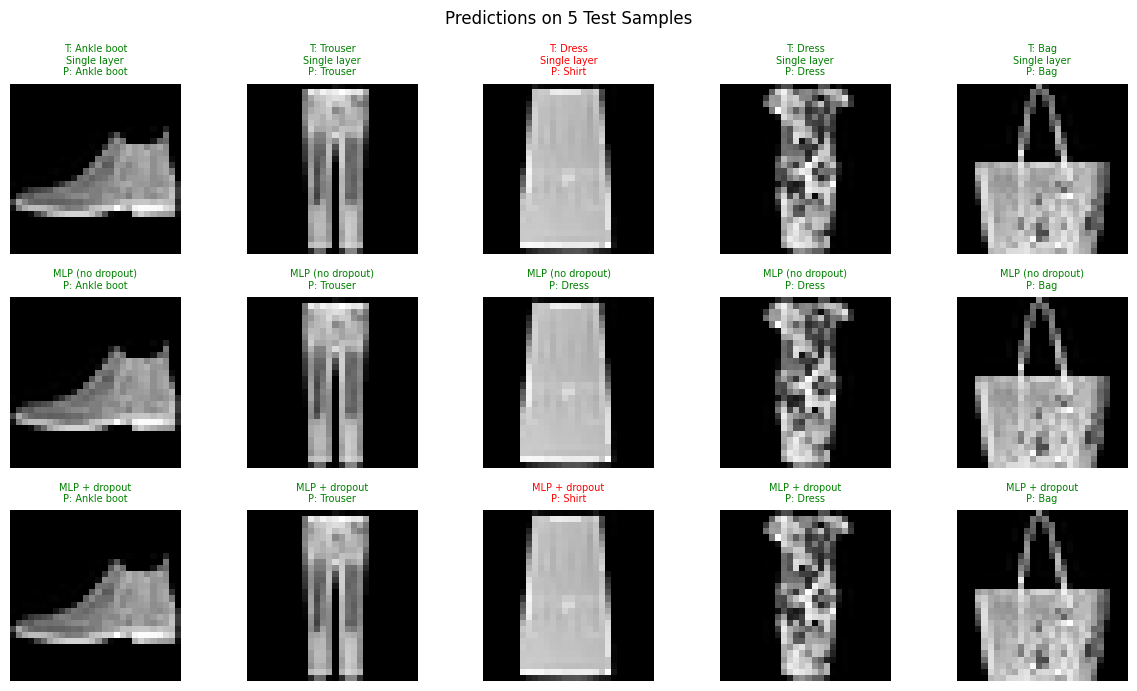

In [29]:
sample_indices = [0, 15, 42, 100, 256]
sample_images = torch.stack([fashion_mnist_test_dataset[i][0] for i in sample_indices])
sample_true_labels = [fashion_mnist_test_dataset[i][1] for i in sample_indices]

fig, axes = plt.subplots(3, 5, figsize=(12, 7))

model_keys_in_plot_order = [
    'single_layer',
    'mlp_no_dropout',
    'mlp_with_dropout',
]

for row_idx, model_key in enumerate(model_keys_in_plot_order):
    model_by_key[model_key].eval()
    with torch.no_grad():
        predicted_label_indices = (
            model_by_key[model_key](sample_images.to(device))
            .argmax(dim=1)
            .cpu()
        )

    for col_idx in range(5):
        ax = axes[row_idx, col_idx]

        # Un-normalize for visualization: x_norm = (x - 0.5) / 0.5  =>  x = x_norm * 0.5 + 0.5
        ax.imshow(sample_images[col_idx].squeeze() * 0.5 + 0.5, cmap='gray')

        is_correct = predicted_label_indices[col_idx].item() == sample_true_labels[col_idx]

        title = (
            f"{plot_label_by_model_key[model_key]}\n"
            f"P: {CLASS_NAMES[predicted_label_indices[col_idx]]}"
        )

        if row_idx == 0:
            title = f"T: {CLASS_NAMES[sample_true_labels[col_idx]]}\n" + title

        ax.set_title(title, fontsize=7, color='green' if is_correct else 'red')
        ax.axis('off')

plt.suptitle('Predictions on 5 Test Samples')
plt.tight_layout()
plt.show()

## Summary

- Single-layer model underfits
- MLP without dropout overfits more
- Dropout reduces overfitting
- Run `tensorboard --logdir=runs` to view logs